<a href="https://colab.research.google.com/github/DhananjayaFdo/Databases-and-Analytics-Assignment/blob/main/setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
print("Loading libraries...")
print("-" * 32)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded ✓")

Loading libraries...
--------------------------------
Libraries loaded ✓


In [38]:


print("Loading files...")
print("-" * 32)

baseUrl = "https://raw.githubusercontent.com/DhananjayaFdo/Databases-and-Analytics-Assignment/refs/heads/main/northstar_dataset";

hubs = pd.read_csv(f'{baseUrl}/hubs.csv')
customers = pd.read_csv(f'{baseUrl}/customers.csv')
drivers = pd.read_csv (f'{baseUrl}/drivers.csv');
vehicles = pd.read_csv (f'{baseUrl}/vehicles.csv');
orders = pd.read_csv (f'{baseUrl}/orders.csv');
deliveries = pd.read_csv (f'{baseUrl}/deliveries.csv');
incidents = pd.read_csv (f'{baseUrl}/incidents.csv');
complaints = pd.read_csv (f'{baseUrl}/complaints.csv');
app_events = pd.read_csv (f'{baseUrl}/app_events.csv');

print("All files loaded ✓")

Loading files...
--------------------------------
All files loaded ✓


In [29]:
print("Data types:")
print("-" * 32)
datasets = {
    'hubs': hubs, 'customers': customers, 'drivers': drivers,
    'vehicles': vehicles, 'orders': orders, 'deliveries': deliveries,
    'incidents': incidents, 'complaints': complaints, 'app_events': app_events
}

print(f"{'File':<15} {'Rows':>6} {'Columns':>8}")
print("-" * 32)
for name, df in datasets.items():
    print(f"{name:<15} {df.shape[0]:>6} {df.shape[1]:>8}")


Data types:
--------------------------------
File              Rows  Columns
--------------------------------
hubs                 8        5
customers          650        9
drivers            170        8
vehicles           120        8
orders            1250       11
deliveries         950       13
incidents          280        7
complaints         320       10
app_events         640       10


In [28]:

print("Missing values:")
print("-" * 32)
for name, df in datasets.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]

    if len(nulls) > 0:
        print(f"[{name}]")
        for col, count in nulls.items():
            pct = round(count / len(df) * 100, 1)
            print(f"  {col}: {count} missing ({pct}%)")
        print()
    else:
        print(f"[{name}] — no missing values ✓\n")

Missing values:
--------------------------------
[hubs] — no missing values ✓

[customers]
  loyalty_score: 20 missing (3.1%)
  preferred_channel: 13 missing (2.0%)

[drivers]
  training_score: 7 missing (4.1%)

[vehicles]
  battery_health_pct: 4 missing (3.3%)

[orders]
  booking_channel: 25 missing (2.0%)

[deliveries]
  delivery_completed_at: 19 missing (2.0%)
  customer_rating_post_delivery: 14 missing (1.5%)

[incidents]
  resolved_hours: 17 missing (6.1%)

[complaints]
  compensation_amount: 16 missing (5.0%)

[app_events]
  order_id: 144 missing (22.5%)



In [32]:
print("Date types:")
print("-" * 32)
for name, df in datasets.items():
    print(f"[{name}]")
    print(df.dtypes.to_string())
    print()

Date types:
--------------------------------
[hubs]
hub_id            object
hub_name          object
zone              object
hub_type          object
capacity_score     int64

[customers]
customer_id              object
age                       int64
home_zone                object
customer_type            object
signup_date              object
loyalty_score           float64
app_engagement_score    float64
preferred_channel        object
account_status           object

[drivers]
driver_id            object
base_zone            object
employment_type      object
years_experience      int64
training_score      float64
driver_rating       float64
shift_preference     object
active_flag           int64

[vehicles]
vehicle_id             object
vehicle_type           object
assigned_zone          object
commission_date        object
battery_health_pct    float64
odometer_km             int64
maintenance_status     object
telematics_version     object

[orders]
order_id                 

In [33]:
print("=== CATEGORIES TO WATCH ===\n")

print("delivery_status:")
print(deliveries['delivery_status'].value_counts(), "\n")

print("driver employment_type:")
print(drivers['employment_type'].value_counts(), "\n")

print("vehicle maintenance_status:")
print(vehicles['maintenance_status'].value_counts(), "\n")

print("order service_type:")
print(orders['service_type'].value_counts(), "\n")

print("complaint_type:")
print(complaints['complaint_type'].value_counts(), "\n")

print("incident_type:")
print(incidents['incident_type'].value_counts(), "\n")

=== CATEGORIES TO WATCH ===

delivery_status:
delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64 

driver employment_type:
employment_type
FullTime    110
PartTime     40
Contract     20
Name: count, dtype: int64 

vehicle maintenance_status:
maintenance_status
Active       67
InRepair     36
Scheduled    17
Name: count, dtype: int64 

order service_type:
service_type
Passenger    341
Parcel       308
Retail       297
Business     165
Medical      139
Name: count, dtype: int64 

complaint_type:
complaint_type
Delay                101
MissedPickup          64
AppIssue              53
DriverBehaviour       51
SupportExperience     20
Billing               16
Damage                15
Name: count, dtype: int64 

incident_type:
incident_type
ProofMissing        46
CustomerNoShow      44
RouteDeviation      43
VehicleFault        37
BatteryAlert        36
AppSyncError        31
TemperatureIssue    29
SafetyNearMiss      14
Name: count, dtype: int64 



In [34]:
# Cell 8 — Preview each file (first 3 rows)
for name, df in datasets.items():
    print(f"\n=== {name.upper()} ===")
    display(df.head(3))


=== HUBS ===


,hub_id,hub_name,zone,hub_type,capacity_score
0,H01,North Exchange,North,Dispatch,82
1,H02,South Link,South,Dispatch,78
2,H03,East Dock,East,Warehouse,74



=== CUSTOMERS ===


,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active



=== DRIVERS ===


...

,incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours
0,I0001,DL00221,BatteryAlert,2024-03-11 23:46:00,Medium,Escalated,12.3
1,I0002,DL00578,BatteryAlert,2024-02-21 10:56:00,Low,Open,9.6
2,I0003,DL00175,TemperatureIssue,2025-04-17 23:22:00,Medium,Open,22.0



=== COMPLAINTS ===


,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41



=== APP_EVENTS ===


,event_id,customer_id,order_id,event_timestamp,event_type,session_id,device_type,zone_context,api_latency_ms,success_flag
0,AE00001,C0488,NaN,2024-08-09 03:25:00,eta_refresh,S19847,Android,north,301,1
1,AE00002,C0595,O00950,2024-02-13 22:29:00,search_route,S32766,Android,SOUTH,60,1
2,AE00003,C0494,O00170,2025-08-11 09:29:00,chat_opened,S99516,iOS,Airport,1118,1


In [35]:
# Cell 9 — Map the relationships between files
print("""
HOW THE FILES CONNECT:
======================

customers (customer_id)
    └──> orders (customer_id)
             └──> deliveries (order_id)
             │        └──> incidents (delivery_id)
             │        └──> drivers (driver_id)
             │        └──> vehicles (vehicle_id)
             │        └──> hubs (hub_id)
             └──> complaints (order_id)

customers (customer_id)
    └──> app_events (customer_id)
    └──> complaints (customer_id)
""")

# Verify the joins work
print("Checking join keys...\n")
print(f"orders → deliveries:  {deliveries['order_id'].isin(orders['order_id']).sum()} of {len(deliveries)} deliveries match an order")
print(f"deliveries → drivers: {deliveries['driver_id'].isin(drivers['driver_id']).sum()} of {len(deliveries)} deliveries match a driver")
print(f"deliveries → vehicles:{deliveries['vehicle_id'].isin(vehicles['vehicle_id']).sum()} of {len(deliveries)} deliveries match a vehicle")
print(f"deliveries → hubs:    {deliveries['hub_id'].isin(hubs['hub_id']).sum()} of {len(deliveries)} deliveries match a hub")
print(f"complaints → orders:  {complaints['order_id'].isin(orders['order_id']).sum()} of {len(complaints)} complaints match an order")


HOW THE FILES CONNECT:

customers (customer_id)
    └──> orders (customer_id)
             └──> deliveries (order_id)
             │        └──> incidents (delivery_id)
             │        └──> drivers (driver_id)
             │        └──> vehicles (vehicle_id)
             │        └──> hubs (hub_id)
             └──> complaints (order_id)

customers (customer_id)
    └──> app_events (customer_id)
    └──> complaints (customer_id)

Checking join keys...

orders → deliveries:  950 of 950 deliveries match an order
deliveries → drivers: 950 of 950 deliveries match a driver
deliveries → vehicles:950 of 950 deliveries match a vehicle
deliveries → hubs:    950 of 950 deliveries match a hub
complaints → orders:  320 of 320 complaints match an order


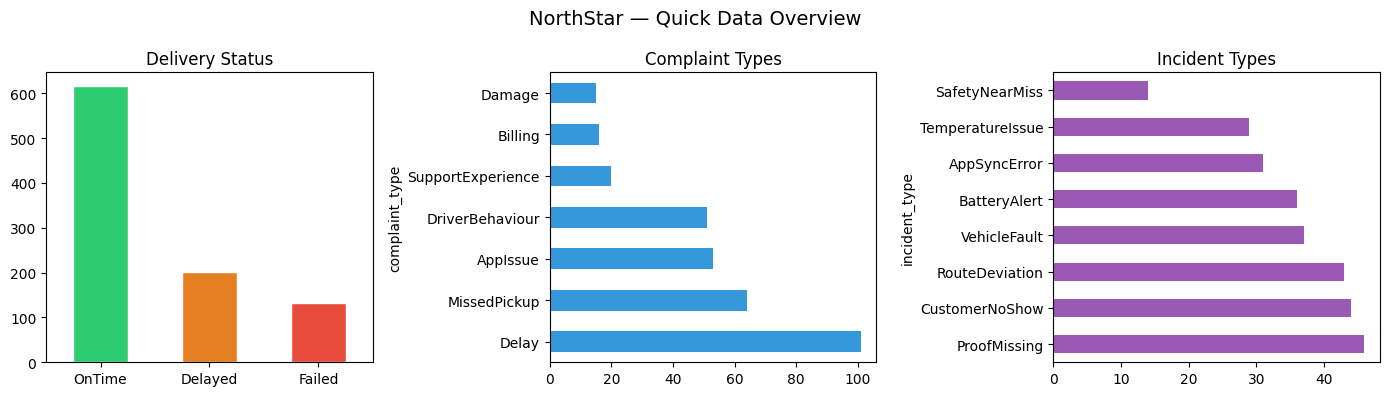

Chart saved ✓


In [45]:
# Cell 10 — Quick summary chart: delivery status overview
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('NorthStar — Quick Data Overview', fontsize=14)

# Delivery status
deliveries['delivery_status'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ecc71','#e67e22','#e74c3c'], edgecolor='white'
)
axes[0].set_title('Delivery Status')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Complaint types
complaints['complaint_type'].value_counts().plot(
    kind='barh', ax=axes[1], color='#3498db'
)
axes[1].set_title('Complaint Types')

# Incident types
incidents['incident_type'].value_counts().plot(
    kind='barh', ax=axes[2], color='#9b59b6'
)
axes[2].set_title('Incident Types')

plt.tight_layout()
plt.savefig('overview_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print("Chart saved ✓")